# Neural Network
- Multiple output heads for different levels
- Weighted cross entropy loss
    -Dynamic weights?

## Module Imports

In [39]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary


## Set Torch Device

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Import

In [41]:
chunksFilePath = Path("GlobalGeoTree-6M/Chunks1Pixel/")

df = torch.load(chunksFilePath / 'SampledData-10Percent-Clean.pth', map_location="cpu", weights_only=False)

In [42]:
df.head()

,ID,longitude,latitude,elevation,slope,aspect,soil_moisture_0_5cm,soil_moisture_5_15cm,soil_moisture_15_30cm,bio01,...,bio15,bio16,bio17,bio18,bio19,level0,level1_family,level2_genus,level3_species,imgDataScaled
1,218607,0.654219,0.275708,0.222149,0.333333,0.604457,0.386760,0.412639,0.415730,0.719723,...,0.438095,0.332330,0.272572,0.430339,0.166521,Deciduous Broadleaf,Fabaceae,Acacia,Acacia heterophylla,"[[tensor(0.6650, dtype=torch.float64), tensor(..."
2,218641,0.653965,0.274870,0.547401,0.102564,0.674095,0.543554,0.579926,0.625468,0.418685,...,0.371429,0.425045,0.417376,0.530599,0.244987,Deciduous Broadleaf,Fabaceae,Acacia,Acacia heterophylla,"[[tensor(0.5702, dtype=torch.float64), tensor(..."
3,218583,0.653824,0.275580,0.420271,0.153846,0.799443,0.452962,0.501859,0.501873,0.519031,...,0.390476,0.396749,0.373083,0.500000,0.222319,Deciduous Broadleaf,Fabaceae,Acacia,Acacia heterophylla,"[[tensor(0.6541, dtype=torch.float64), tensor(..."
4,218632,0.654311,0.275680,0.371997,0.051282,0.077994,0.348432,0.371747,0.378277,0.570934,...,0.400000,0.379892,0.344123,0.481771,0.205754,Deciduous Broadleaf,Fabaceae,Acacia,Acacia heterophylla,"[[tensor(0.1485, dtype=torch.float64), tensor(..."
5,218652,0.653826,0.275303,0.429445,0.064103,0.565460,0.606272,0.657992,0.670412,0.522491,...,0.390476,0.393137,0.369676,0.496094,0.221447,Deciduous Broadleaf,Fabaceae,Acacia,Acacia heterophylla,"[[tensor(0.9013, dtype=torch.float64), tensor(..."


# Data Loading

In [43]:
# Extract tensor data into 120 new columns (10 bands × 12 months)
num_months = 12
num_bands = 10

column_names = [f"Band_{b:02d}_Month_{m:02d}" for b in range(num_bands) for m in range(num_months)]

tensor_data = df['imgDataScaled'].apply(lambda tensor: tensor.T.flatten().numpy().astype(np.float32))
tensor_df = pd.DataFrame(tensor_data.tolist(), columns=column_names)

df = pd.concat([df.reset_index(drop=True), tensor_df], axis=1)
#df.drop(columns=['imgDataScaled'], inplace=True)
 
print(f"New dataframe shape: {df.shape}")

New dataframe shape: (575394, 153)


In [44]:
levelsColumns = [col for col in df.columns if 'level' in col]
imgDataCols = [col for col in df.columns if 'Band_' in col]

X = df.drop(columns=levelsColumns+['ID', 'imgDataScaled'])
Y = df[levelsColumns]

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y['level3_species'])

In [ ]:
batch_size = 128

# Convert features to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32, device=device)

# Convert labels to integers and create mapping for each level
label_encoders = {}
y_train_dict = {}
y_test_dict = {}

for col in levelsColumns:
    # Combine train and test to create consistent label encoding
    all_labels = pd.concat([Y_train[col], Y_test[col]])
    codes, uniques = pd.factorize(all_labels)
    label_encoders[col] = uniques
    
    # Encode train and test labels
    y_train_encoded = pd.factorize(Y_train[col])[0]
    y_test_encoded = pd.factorize(Y_test[col])[0]
    
    # Map test labels using train+test mapping for consistency
    y_train_dict[col] = torch.tensor(y_train_encoded, dtype=torch.long, device=device)
    y_test_dict[col] = torch.tensor(y_test_encoded, dtype=torch.long, device=device)

# Custom dataset class to handle multiple outputs
class MultiLabelDataset(TensorDataset):
    def __init__(self, features, targets_dict):
        self.features = features
        self.targets_dict = targets_dict
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        x = self.features[idx]
        y = {col: self.targets_dict[col][idx] for col in self.targets_dict.keys()}
        return x, y

# Create datasets and dataloaders
train_dataset = MultiLabelDataset(X_train_tensor, y_train_dict)
test_dataset = MultiLabelDataset(X_test_tensor, y_test_dict)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train loader: {len(train_loader)} batches of {batch_size}")
print(f"Test loader: {len(test_loader)} batches of {batch_size}")

Train loader: 3597 batches of 128
Test loader: 900 batches of 128
Target levels: ['level0', 'level1_family', 'level2_genus', 'level3_species']


# Network Definition

## Class

In [65]:
class NN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_sizes):
        super(NN, self).__init__()
        # BXFCY: Block X, Fully Connected Layer Y
        # BXFC0 come from previous block output level
        # BXFC1 comes directly from last model state
        
        # Preserve the level key order as provided
        self.level_keys = list(output_sizes.keys())
        
        blockStepper = 0
        self.B1FC1 = nn.Linear(input_size, hidden_sizes[blockStepper])
        self.B1ReLU1 = nn.ReLU()
        self.B1FC2 = nn.Linear(hidden_sizes[blockStepper], hidden_sizes[blockStepper])
        self.B1ReLU2 = nn.ReLU()
        self.L0Output = nn.Linear(hidden_sizes[blockStepper], output_sizes['level0'])

        blockStepper += 1
        self.B2FC0 = nn.Linear(output_sizes['level0'], hidden_sizes[blockStepper])
        self.B2FC1 = nn.Linear(hidden_sizes[blockStepper-1], hidden_sizes[blockStepper])
        self.B2ReLU1 = nn.ReLU()
        self.B2FC2 = nn.Linear(hidden_sizes[blockStepper], hidden_sizes[blockStepper])
        self.B2ReLU2 = nn.ReLU()
        self.L1Output = nn.Linear(hidden_sizes[blockStepper], output_sizes['level1_family'])

        blockStepper += 1
        self.B3FC0 = nn.Linear(output_sizes['level1_family'], hidden_sizes[blockStepper])
        self.B3FC1 = nn.Linear(hidden_sizes[blockStepper-1], hidden_sizes[blockStepper])
        self.B3ReLU1 = nn.ReLU()
        self.B3FC2 = nn.Linear(hidden_sizes[blockStepper], hidden_sizes[blockStepper])
        self.B3ReLU2 = nn.ReLU()
        self.L2Output = nn.Linear(hidden_sizes[blockStepper], output_sizes['level2_genus'])

        blockStepper += 1
        self.B4FC0 = nn.Linear(output_sizes['level2_genus'], hidden_sizes[blockStepper])
        self.B4FC1 = nn.Linear(hidden_sizes[blockStepper-1], hidden_sizes[blockStepper])
        self.B4ReLU1 = nn.ReLU()
        self.B4FC2 = nn.Linear(hidden_sizes[blockStepper], hidden_sizes[blockStepper])
        self.B4ReLU2 = nn.ReLU()
        self.L3Output = nn.Linear(hidden_sizes[blockStepper], output_sizes['level3_species'])
        
    def forward(self, x):
        # Block 1 for Level 0
        x = self.B1FC1(x)
        x = self.B1ReLU1(x)
        x = self.B1FC2(x)
        x = self.B1ReLU2(x)
        level0_out = self.L0Output(x)

        # Block 2 for Level 1
        x_from_level0 = self.B2FC0(level0_out)  
        x_from_hidden = self.B2FC1(x)            
        x = torch.add(x_from_level0, x_from_hidden)  
        x = self.B2ReLU1(x)
        x = self.B2FC2(x)
        x = self.B2ReLU2(x)
        level1_out = self.L1Output(x)

        # Block 3 for Level 2
        x_from_level1 = self.B3FC0(level1_out)
        x_from_hidden = self.B3FC1(x)
        x = torch.add(x_from_level1, x_from_hidden)
        x = self.B3ReLU1(x)
        x = self.B3FC2(x)
        x = self.B3ReLU2(x)
        level2_out = self.L2Output(x)

        # Block 4 for Level 3
        x_from_level2 = self.B4FC0(level2_out)
        x_from_hidden = self.B4FC1(x)
        x = torch.add(x_from_level2, x_from_hidden)
        x = self.B4ReLU1(x)
        x = self.B4FC2(x)
        x = self.B4ReLU2(x)
        level3_out = self.L3Output(x)

        level_outputs = [level0_out, level1_out, level2_out, level3_out]
        outputs = {k: v for k, v in zip(self.level_keys, level_outputs)}

        return outputs

## Hyperparameters

In [66]:
epochs = 10

input_size = X_train_tensor.shape[1]
output_sizes = {col: len(label_encoders[col]) for col in levelsColumns}
hidden_sizes = [128, 128, 64, 64] # Hidden layer sizes for each block

labelSmootings = [0.1, 0.1, 0.1, 0.1] # Label smoothing values for CE for each level
lossWeights = np.array([0.4, 0.2, 0.001, 0.001])  # weights for each level loss in total loss calculation

lossWeights /= np.sum(lossWeights)  # Normalize weights

## Loss Function

In [67]:
def weightedLoss(outputs, targets, label_smoothings, weights):
    total_loss = 0.0
    
    # Iterate through each level with its corresponding smoothing and weight
    for idx, level in enumerate(outputs.keys()):
        # Create criterion with label smoothing for this level
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothings[idx])
        
        # Compute loss for this level
        level_loss = criterion(outputs[level], targets[level])
        
        # Add weighted loss to total
        total_loss += weights[idx] * level_loss
    
    return total_loss

## F1 Score

In [68]:
def computeF1Scores(outputs, targets):
    f1_scores = {}
    for level in outputs.keys():
        preds = torch.argmax(outputs[level], dim=1).cpu().numpy()
        trues = targets[level].cpu().numpy()
        
        tp = np.sum((preds == trues) & (trues != -1))
        fp = np.sum((preds != trues) & (preds != -1))
        fn = np.sum((preds != trues) & (trues != -1))
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
        
        f1_scores[level] = f1
    return f1_scores

## Model Initialisation

In [69]:
model = NN(input_size, hidden_sizes, output_sizes).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

summary(model, input_size=(1, input_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 128]          18,944
              ReLU-2               [-1, 1, 128]               0
            Linear-3               [-1, 1, 128]          16,512
              ReLU-4               [-1, 1, 128]               0
            Linear-5                 [-1, 1, 4]             516
            Linear-6               [-1, 1, 128]             640
            Linear-7               [-1, 1, 128]          16,512
              ReLU-8               [-1, 1, 128]               0
            Linear-9               [-1, 1, 128]          16,512
             ReLU-10               [-1, 1, 128]               0
           Linear-11               [-1, 1, 205]          26,445
           Linear-12                [-1, 1, 64]          13,184
           Linear-13                [-1, 1, 64]           8,256
             ReLU-14                [-1

# Training Loop

In [ ]:
bestF1 = {col: [] for col in levelsColumns}

trainF1Scores = {col: [] for col in levelsColumns}
trainLosses = []
testF1Scores = {col: [] for col in levelsColumns}
testLosses = []

for epoch in range(epochs):
    model.train()
    trainLoss = 0.0
    trainF1Epoch = {col: 0.0 for col in levelsColumns}

    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = {col: targets[col].to(device) for col in targets.keys()}

        optimiser.zero_grad()
        outputs = model(data)

        loss = weightedLoss(outputs, targets, labelSmootings, lossWeights)
        loss.backward()
        optimiser.step()

        trainLoss += loss.item() * batch_size
        
        # Compute F1 scores for this batch
        batch_f1 = computeF1Scores(outputs, targets)
        for col in levelsColumns:
            trainF1Epoch[col] += batch_f1[col] * data.size(0)
        

    model.eval()
    testLoss = 0.0
    testF1Epoch = {col: 0.0 for col in levelsColumns}
    
    with torch.no_grad():
        for batch_idx, (data, targets) in enumerate(test_loader):
            data = data.to(device)
            targets = {col: targets[col].to(device) for col in targets.keys()}

            outputs = model(data)
            loss = weightedLoss(outputs, targets, labelSmootings, lossWeights)

            testLoss += loss.item() * batch_size
            
            # Compute F1 scores for this batch
            batch_f1 = computeF1Scores(outputs, targets)
            for col in levelsColumns:
                testF1Epoch[col] += batch_f1[col] * data.size(0)
    
    trainLoss /= len(train_loader.dataset)
    testLoss /= len(test_loader.dataset)
    
    # Average F1 scores
    for col in levelsColumns:
        trainF1Epoch[col] /= len(train_loader.dataset)
        testF1Epoch[col] /= len(test_loader.dataset)
        trainF1Scores[col].append(trainF1Epoch[col])
        testF1Scores[col].append(testF1Epoch[col])

    trainLosses.append(trainLoss)
    testLosses.append(testLoss)


    print(f"Epoch {epoch+1} | Train Loss: {trainLoss:.4f} | Test Loss: {testLoss:.4f}")




Epoch 1 | Train Loss: 1.9029 | Test Loss: 2.5633
Epoch 2 | Train Loss: 1.8305 | Test Loss: 2.5766
Epoch 3 | Train Loss: 1.8056 | Test Loss: 2.6023
Epoch 4 | Train Loss: 1.7895 | Test Loss: 2.5942
Epoch 5 | Train Loss: 1.7785 | Test Loss: 2.6301
Epoch 6 | Train Loss: 1.7702 | Test Loss: 2.5822
Epoch 7 | Train Loss: 1.7636 | Test Loss: 2.6103
Epoch 8 | Train Loss: 1.7579 | Test Loss: 2.6287
Epoch 9 | Train Loss: 1.7536 | Test Loss: 2.6316
Epoch 10 | Train Loss: 1.7497 | Test Loss: 2.6502


## Losses and F1 Plot

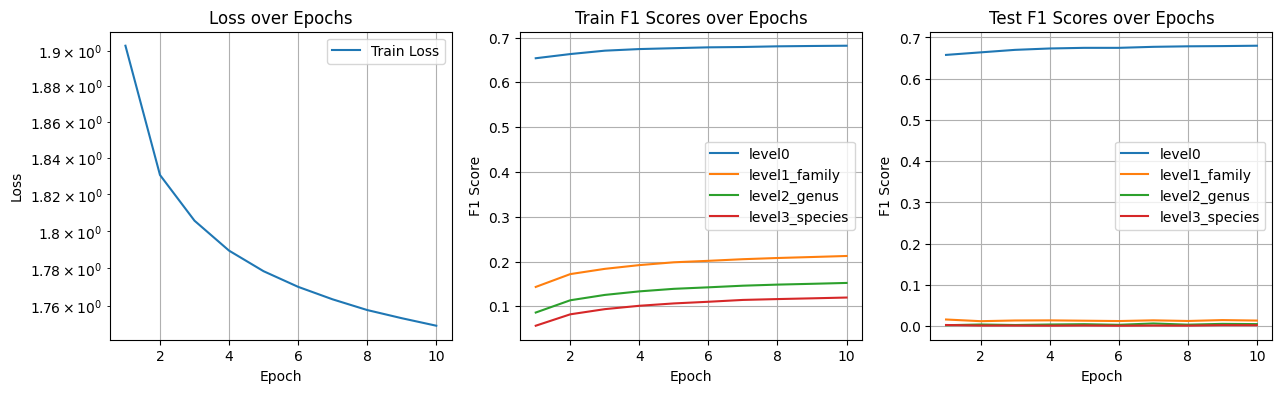

In [ ]:
trainLosses = np.array(trainLosses)
testLosses = np.array(testLosses)

figLoss, axLoss = plt.subplots(ncols=3, figsize=(15, 4))

epochArr = np.arange(1, trainLosses.shape[0]+1, 1)

axLoss[0].plot(epochArr, trainLosses, label='Train Loss')
axLoss[0].plot(epochArr, testLosses, label='Test Loss')
axLoss[0].set_title('Loss over Epochs')
axLoss[0].set_xlabel('Epoch')
axLoss[0].set_ylabel('Loss')
axLoss[0].grid()
axLoss[0].set_yscale('log')
axLoss[0].legend()

# Train F1 scores
axTrainF1 = axLoss[1]
for col in levelsColumns:
    axTrainF1.plot(epochArr, trainF1Scores[col], label=f'{col}')

axTrainF1.set_title('Train F1 Scores over Epochs')
axTrainF1.set_xlabel('Epoch')
axTrainF1.set_ylabel('F1 Score')
axTrainF1.grid()
axTrainF1.legend()

# Test F1 scores
axTestF1 = axLoss[2]
for col in levelsColumns:
    axTestF1.plot(epochArr, testF1Scores[col], label=f'{col}')

axTestF1.set_title('Test F1 Scores over Epochs')
axTestF1.set_xlabel('Epoch')
axTestF1.set_ylabel('F1 Score')
axTestF1.grid()
axTestF1.legend()

# To Do

- [] Training loop
- [] loss function
- [] test run on level0 and level1
- [] expand to level2 and level3
- [] hyperparameter tuning